# Exercises for Section 2.1 Discrete random variables 

This notebook contains the exercises from [Section 2.1 Discrete random variables](https://minireference.com/static/excerpts/noBSstats_part1_preview.pdf#page=42) of the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={'figure.figsize': (4,2)},
)

%config InlineBackend.figure_format = 'retina'

In [3]:
# Set pandas precision
pd.set_option("display.precision", 2)

In [4]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

## Exercies 1

### E2.1

Compute the probability of the event $\{2 \leq D \leq 5\}$ for the
die-roll random variable $D \sim \mathcal{U}_d(1,6)$ from Example 2.

In [5]:
# Define the probability mass function for the random variable D
def fD(d):
    if d in [1,2,3,4,5,6]:
        return 1/6
    else:
        return 0

<!-- @solution -->
To compute the probability $\textrm{Pr}(\{2 \leq D \leq 5\})$,
we sum the values of the probability mass function for all outcomes in the set:
$f_D(2) + f_D(3) + f_D(4) + f_D(5)$.

In [6]:
# @solution
sum([fD(d) for d in [2,3,4,5]])

0.6666666666666666

### E2.2

The random variable $D_4 \sim \mathcal{U}_d(1,4)$
describes the outcome of rolling a tetrahedral (four-sided) die.
The sample space is $\{1,2,3,4\}$.
Assuming the die is fair,
what is the probability mass function for the random variable $D_4$?

In [7]:
# @solution
# Define the probability mass function for the random variable D4
def fD4(d):
    if d in [1,2,3,4]:
        return 1/4
    else:
        return 0

[fD4(d) for d in range(1,4+1)]

[0.25, 0.25, 0.25, 0.25]

<!-- @solution -->
The situation is analogous to the six-sided die $D$, but this time the
sample space has four possible outcomes, so the probability of each
outcome is $\frac{1}{4}$.

### E2.3

Consider the random variable $Y$ defined over the sample space
$\mathcal{Y} = \{1,2,3\}$. A colleague published a graph of the
probability mass function $f_Y$, but forgot to label the vertical axis.
Can you compute the probability value $f_Y(3)$ from this graph?

![](./attachments/prob/exercise_unlabelled_pmf_plot.png)

<!-- @solution -->
We use the grid to measure the heights of the stem lines: 4 units, 10
units, and 6 units, for a total of 20 units. The sum of the heights
corresponds to the total probability $1$. We can obtain the probability
$f_Y(3)$ by dividing the height of the $y=3$ stem by the total height:
$f_Y(3)=6/20=0.3$.

### E2.4

Calculate the probability $\textrm{Pr}(D \in \{5,6\})$ for the random
variable $D \sim \mathcal{U}_d(1,6)$, given that
$\textrm{Pr}(D \in \{1,2,3,4\}) = \frac{4}{6}$.

<!-- @solution -->
Define $A$ as the set of outcomes $\{5,6\}$,
which is a subset of the sample space $\{1,2,3,4,5,6\}$ for the random variable $D$.
The complement of $A$ is $A^c= \{1,2,3,4\}$,
and we know $ \Pr(A^c)= \frac{4}{6}$.
Applying the complement rule,
we obtain $\Pr(A) = 1 - \Pr(A^c)  = 1 - \frac{4}{6} = \frac{2}{6}$.

## Exercies 2

### E2.5

Calculate $\textrm{Pr}(\{10 \leq H \leq 30 \})$ using the Python CDF
function $\texttt{FH} = F_H$ of the random variable $H$ that we
introduced in Example 3.

In [8]:
import numpy as np
import math

def fH(h):
    lam = 20
    return lam**h * np.exp(-lam) / math.factorial(h)

def FH(b):
    b = int(b)  # round b to nearest integer
    return sum([fH(h) for h in range(0,b+1)])

In [9]:
# @solution
FH(30) - FH(10-1)

0.9815299064117703

### E2.6

The random variable $D \sim \mathcal{U}_d(1,6)$ from Example 2 describes
the roll of a $6$-sided die. Compute the following values of its
cumulative distribution function: $F_D(1)$, $F_D(2)$, $F_D(3)$,
$F_D(4)$, $F_D(5)$, $F_D(6)$.

In [10]:
# @solution
# Define the probability mass function of the random variable D
def fD(d):
    if d in [1,2,3,4,5,6]:
        return 1/6
    else:
        return 0

def FD(b):
    b = int(b)  # round b to nearest integer
    return sum([fD(d) for d in range(0,b+1)])

In [11]:
# @solution
FD(1), FD(2), FD(3), FD(4), FD(5), FD(6)

(0.16666666666666666,
 0.3333333333333333,
 0.5,
 0.6666666666666666,
 0.8333333333333333,
 1.0)

### E2.7

Draw the graph of the cumulative distribution function $F_D$ by hand
using the values obtained in the previous exercise.

In [12]:
# @studentprompt
# Prepare a continuous list of inputs
bs = np.linspace(0, 7, 1000)

# Evaluate the CDF for the list of inputs
FDs = [FD(b) for b in bs]

# Generate a line plot


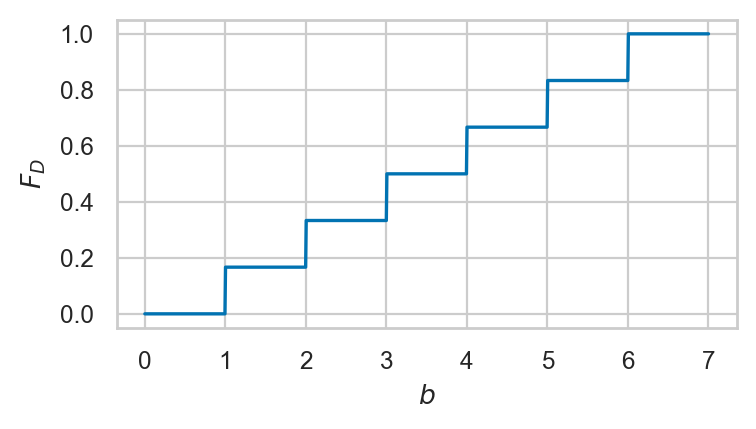

In [13]:
# @solution
# Prepare a continuous list of inputs
bs = np.linspace(0, 7, 1000)

# Evaluate the CDF for the list of inputs
FDs = [FD(b) for b in bs]

# Generate a line plot
ax = sns.lineplot(x=bs, y=FDs)
ax.set_xlabel('$b$')
ax.set_ylabel('$F_D$');

### E2.8

Compute the median of the random variable
$H \sim \mathrm{Pois}(\lambda=20)$ from Example 3.
The median corresponds to the value $F_H^{-1}(\frac{1}{2})$.

Hint: The answer is the smallest value of $b$ such that $F_H(b) \geq 0.5$.

Hint: Evaluate the Python function `FH` for the inputs $\texttt{h}=18$,
$\texttt{h}=19$, $\texttt{h}=20$, $\texttt{h}=21$, $\texttt{h}=22$ to
find the smallest value of `h` such that `FH(h)` is greater than or
equal to $0.5$.

In [14]:
import numpy as np
import math

def fH(h):
    lam = 20
    return lam**h * np.exp(-lam) / math.factorial(h)

def FH(b):
    b = int(b)  # round b to nearest integer
    return sum([fH(h) for h in range(0,b+1)])



In [15]:
# @solution
FH(18), FH(19)

(0.3814219494471548, 0.47025726683924)

In [16]:
# @solution
FH(20)

0.5590925842313252

<!-- @solution -->
We observe that `FH(18)` and `FH(19)` are both less than $0.5$.
We then evaluate `FH(20)` to obtain $0.559 > 0.5$,
which means $h=20$ is the smallest value for which $F_H$ is greater than or equal to $0.5$.
The median is therefore $F_H^{-1}(\frac{1}{2})=20$.

### E2.9

Compute the position of the first quartile $F_H^{-1}(0.25)$ of the
random variable $H \sim \mathrm{Pois}(\lambda=20)$ from Example 3.

Hint: Use the same strategy as in the previous exercise.

In [17]:
# @solution
FH(15), FH(16), FH(17)

(0.15651313463974303, 0.22107420155444096, 0.29702839792467384)

<!-- @solution -->
So $F_H^{-1}(0.25) = 17$.
This is the smallest value $b$ for which $F_H(b)$ is greater than $0.25$.

In [18]:
# @solution
# ALT. by calling the inverse-CDF function on rvH object
from scipy.stats import poisson
rvH = poisson(20)
rvH.ppf(0.25)

17.0

## Exercies 3


### E2.10

Consider a gambling game involving a coin toss random variable $C$
with winning function $w(c)$
defined as $w(\texttt{heads}) = \$1.90$ and $w(\texttt{tails}) = \$0$.
Calculate the expected value $\mathbb{E}_C[w(C)]$.

In [19]:
# @studentprompt
# Define the probability mass function for the random variable C
def fC(c):
    if c in ["heads", "tails"]:
        return 1/2
    else:
        return 0

# Define the winning function
def w(c):
    ...


In [20]:
# @solution
# Define the probability mass function for the random variable C
def fC(c):
    if c in ["heads", "tails"]:
        return 1/2
    else:
        return 0

# Define the winning function
def w(c):
    if c == "heads":
        return 1.90
    else:
        return 0

# Compute the expected value
sum([w(c) * fC(c) for c in {"heads", "tails"}])

0.95

#### E2.11

Compute the expectation $\mathbb{E}_D[u(D)]$, where
$D \sim \mathcal{U}_d(1,6)$ is a fair die, and $u(5)=\$3$, $u(6)=\$4$,
and $u(d)=\$0$ for $d \in \{1,2,3,4\}$.

In [21]:
# @studentprompt
# Define the probability mass function of the random variable D
def fD(d):
    if d in [1,2,3,4,5,6]:
        return 1/6
    else:
        return 0

# Define the winnings function
def u(d):
    ...

# Compute the expected value


In [22]:
# @solution
# Define the probability mass function of the random variable D
def fD(d):
    if d in [1,2,3,4,5,6]:
        return 1/6
    else:
        return 0

# Define the winnings function
def u(d):
    if d == 6:
        return 4
    elif d == 5:
        return 3
    else:
        return 0

# Compute the expected value
sum([u(d)*fD(d) for d in range(1,6+1)])

1.1666666666666665

### E2.12

Consider the random variable $Y=mX+b$. Starting from the definition
$\sigma^2_Y =  \mathbb{E}_X[(Y-\mu_Y)^2]$, prove that
$\sigma^2_Y = m^2\sigma^2_X$.

<!-- @solution -->
We start by computing the mean of $Y=mX+b$:
$$\mu_Y = \mathbb{E}_Y[Y] = \mathbb{E}_X[mX+b] = \mathbb{E}_X[mX]+\mathbb{E}_X[b] = m\mathbb{E}_X[X] +b = m \mu_X +b.$$
We plug in the value of $\mu_Y$ into the definition of the variance
$\sigma^2_Y$, and do some simplifications: $$\sigma^2_Y
                    = \mathbb{E}_Y[(Y-\mu_Y)^2]
                    = \mathbb{E}_X[\big(mX+b - (m \mu_X +b)\big)^2]
                    = \mathbb{E}_X[\big(m(X-\mu_X) \big)^2],$$ which is
equivalent to $\mathbb{E}_X[\big(m(X-\mu_X) \big)^2]$. Next, we take the
constant $m^2$ outside the exception to get
$\mathbb{E}_X[\big(m(X-\mu_X) \big)^2] = m^2\mathbb{E}_X[(X-\mu_X)^2]$.
We can recognize $\mathbb{E}_X[(X-\mu_X)^2]$ as the definition of
$\sigma^2_X$. We have thus shown that $\sigma^2_Y = m^2\sigma^2_X$.

### E2.13

Compute the expected value of the random variable $D_{20}$, which
describes the outcome of rolling a $20$-sided die with distribution
$f_{D_{20}}(d) = \frac{1}{20}$ for all $d$ in $\{1,2,3,\ldots,20\}$.

In [23]:
# @studentprompt
# Define the probability mass function of the random variable D20
def fD20(d):
    ...

# Expected value of the random variable D20


In [24]:
# @solution
# Define the probability mass function of the random variable D20
def fD20(d):
    if d in range(1,20+1):
        return 1/20
    else:
        return 0

# Expected value of the random variable D20
sum([d*fD20(d) for d in range(1,20+1)])

10.5

## Exercies 4

### E2.14

Let's reproduce the calculations related to the die-roll random variable $D$,
which we introduced in Example 2.  

**a)** In a Jupyter notebook, import the `randint` (discrete uniform
distribution) model from `scipy.stats`.  
**b)** Create the computer model for
the random variable `rvD` by initializing using
`rvD = randint(alpha,beta+1)` for an appropriate choice of start and
stop parameters `alpha` and `beta`.   
**c)** Evaluate the probability mass
function of the random variable $D$ (`rvD.pmf`) for all inputs $d$ in
the range from $1$ to $6$. Do the values obey Kolmogorov's axioms of
probability?   
**d)** Find the value of the cumulative distribution function
$F_D(4)$ by computing the `sum` of `rvD.pmf` values.   
**e)** Compute $F_D(4)$
using the CDF method `rvD.cdf`, and confirm you get the same value as in
your previous answer.   
**f)** Compute the mean $\mu_D$ and the variance
$\sigma_D^2$ of the random variable $D$ by calling the appropriate
methods on `rvD`.   
**g)** Compute the expected value $\mathbb{E}_D[w(D)]$ of a
game described in Example 4, with the winnings function $w$
```
def w(d):
    if d == 6:
        return 5
    else:
        return 0
```

In [25]:
# @solution
# a)
from scipy.stats import randint


In [26]:
# @solution
# b)
rvD = randint(1,6+1)
rvD

In [27]:
# @solution
# c) f_D values
[rvD.pmf(d) for d in range(1,6+1)]

[0.16666666666666666,
 0.16666666666666666,
 0.16666666666666666,
 0.16666666666666666,
 0.16666666666666666,
 0.16666666666666666]

In [28]:
# @solution
# c) Check Kolmogorov's unit total axiom:
sum([rvD.pmf(d) for d in range(1,6+1)])

0.9999999999999999

In [29]:
# @solution
# e) FD(4) using summation
sum([rvD.pmf(d) for d in range(1,4+1)])

0.6666666666666666

In [30]:
# @solution
# e) FD(4) by calling the `.cdf` method
rvD.cdf(4)

0.6666666666666666

In [31]:
# @solution
# f) mean and variance
# mu =      sigma^2 =
rvD.mean(), rvD.var()

(3.5, 2.9166666666666665)

In [32]:
# @solution
# g) expected value
def w(d):
    if d == 6:
        return 5
    else:
        return 0

# Compute the expected value
sum([w(d)*rvD.pmf(d) for d in range(1,6+1)])

0.8333333333333333

In [33]:
# @solution
# BTW, calling `rvD.expect(w)` raises an error:
# ValueError: The truth value of an array is ambiguous.
#             Use a.any() or a.all()

<!-- @solution -->
This error occurs because the Python function `w` chokes
if we pass it an `array` of inputs to evaluate,
which is what the method `rvD.expect` does (for efficiency reasons).

We can easily solve this by "vectorizing" the function using the NumPy helper method `vectorize`, which makes any Python function work with vector inputs (arrays of numbers).

In [34]:
# @solution
# g) ALT. expected value calculations
# Create a "vectorized" version of the function `w`
# then use the method `rvD.expect`
vw = np.vectorize(w)
rvD.expect(vw)

0.8333333333333333

### E2.15

Consider the random variable $D_{20}$
which describes the outcome of rolling a $20$-sided die.
The random variable $D_{20}$ follows the discrete uniform distribution
$\mathcal{U}_d(1,20)$,
which assigns equal probability to all values in
the sample space $\{1, 2, 3, \ldots, 20\}$.  
**a)** Create the computer model for the random variable `rvD20` using the code
`rvD20 = randint(alpha,beta+1)`, for an appropriate choice of start and
stop parameters `alpha` and `beta`.   
**b)** Evaluate the probability mass
function of the random variable $D_{20}$ (`rvD20.pmf`) for the input
$d=7$.   
**c)** Compute $F_{D_{20}}(4)$ using the `sum` of `rvD20.pmf` values
over the appropriate `range` of inputs.   
**d)** Compute $F_{D_{20}}(4)$ using
the CDF method `rvD20.cdf`.   
**e)** Compute the mean $\mu_{D_{20}}$, the
standard deviation $\sigma_{D_{20}}$, and the variance
$\sigma_{D_{20}}^2$ of the random variable $D_{20}$.

In [35]:
# @studentprompt
from scipy.stats import randint

rvD20 = ...

In [36]:
# @solution
# a)
from scipy.stats import randint
rvD20 = randint(1,20+1)

In [37]:
# @solution
# b)
rvD20.pmf(7)

0.05

In [38]:
# @solution
# c)
sum([rvD20.pmf(d) for d in range(1,4+1)])

0.2

In [39]:
# @solution
# d)
rvD20.cdf(4)

0.2

In [40]:
# @solution
# e)
rvD20.mean(), rvD20.std(), rvD20.var()

(10.5, 5.766281297335398, 33.25)

### E2.16

Computer memory
errors can be modelled using the Poisson distribution. Consider the
random variable $M$ that describes the number of memory errors that
occur during a given time period. You know from past observations that
the average number of errors is $40$.  
**a)** Import the `poisson` model from `scipy.stats`.   
**b)** Create the random
variable `rvM` from the `poisson` model to describe the number of memory
errors by choosing the appropriate parameter $\lambda$ when initializing
the model.   
**c)** Compute the mean $\mu_M$, the variance $\sigma_M^2$, and the
standard deviation $\sigma_M$ of the random variable $M$.   
**d)** Compute
$\textrm{Pr}(\{33 \leq M \leq 44\})$ using the `sum` of `rvM.pmf` values
over the appropriate `range` of inputs.   
**e)** Compute
$\textrm{Pr}(\{33 \leq M \leq 44\})$ using the CDF method `rvM.cdf`.  
**f)** 
Find the smallest value $m_{0.95}$ such that
$\textrm{Pr}(\{M \leq m_{0.95} \}) \geq 0.95$.   
**g)** Generate $10$
observations from the random variable `rvM`.

In [41]:
# @solution
# a)
from scipy.stats import poisson

In [42]:
# @solution
# b)
rvM = poisson(40)

In [43]:
# @solution
# c)
rvM.mean(), rvM.var(), rvM.std()

(40.0, 40.0, 6.324555320336759)

In [44]:
# @solution
# d)
sum([rvM.pmf(m) for m in range(33,44+1)])

0.650381362278227

In [45]:
# @solution
# e)
rvM.cdf(44) - rvM.cdf(33-1)

0.6503813622782226

In [46]:
# @solution
# f)
rvM.ppf(0.95)

51.0

In [47]:
# @solution
# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# g)
rvM.rvs(10)

array([38, 44, 33, 42, 47, 33, 36, 39, 42, 36])